# Основи статистики

<table>
    <tr>
        <td>
            <h2>Завдання 1</h2>
Потрібно проаналізувати дані транзакцій інтернет-магазину та візуалізувати розподіл сум замовлень. Усе необхідно запрограмувати в Python з використанням pandas, NumPy і Matplotlib.
            <ul>
                <li>Завантажте дані з CSV у таблицю.</li>
                <li>Виведіть перші рядки та інформацію про стовпці.</li>
                <li>Визначте кількість пропусків за кожним стовпчиком.</li>
                <li>Побудуйте зведення за "amount": кількість, середнє, медіана, мінімум, максимум, квартилі та перцентилі.</li>
                <li>Побудуйте гістограму "amount" і коробчату діаграму.</li>
                <li>Видаліть пропуски в "amount" і повторіть розрахунок зведення.</li>                
                <li>Виведіть усі результати та графіки.</li>
            </ul>
        </td>
        <td>
            Характеристики сукупності (набору) даних:<br/>
            <b>Середнє значення</b> - одне значення для набору, яке розраховується по всій сукупності. Частіше за все, мова іде про середнє арифметичне - сума значень, поділена на їх кількість.<br/>
            <b>медіана</b> - значення, що ділить сукупність навпіл: однакова кількість елементів є більшими та меншими за медіану. Наприклад, є послідовність (1, 2, 3, 100): середнє 26.5, медіана 2.5<br/>
            <b>квартилі</b> - подібна до медіани задача тільки з діленням на чотири частини: Q1 - перша чверть,..., Q4 - четверта.<br/>
            <b>перцентилі</b> - величина, що задає відсотковий поділ групи (сукупності): 0-й персентиль - мінімум, 100-й - максимум, 25-й - Q1, 50-й - медіана або Q2
        </td>
    </tr>
</table>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown as md

In [2]:
sales = pd.read_csv("Pract2_4_sales.csv")
sales.head()

,Product,Price,Amount
0,Wireless Mouse,24.99,3
1,Mechanical Keyboard,89.50,2
2,USB-C Cable,12.99,5
3,Laptop Stand,34.99,1
4,Bluetooth Speaker,59.99,2


In [3]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Product  99 non-null     str    
 1   Price    99 non-null     float64
 2   Amount   99 non-null     int64  
dtypes: float64(1), int64(1), str(1)
memory usage: 2.4 KB


In [4]:
def stat(df):  # квартилі та перцентилі.
    return md( "\n".join( (
        "|Показник|Значення|",
        "|-|-|",
        f"|кількість|{len(df['Amount'].index)}|",
        f"|середнє|{df['Amount'].mean():.1f}|",
        f"|медіана|{df['Amount'].median()}|",
        f"|мінімум|{df['Amount'].min()}|",
        f"|максимум|{df['Amount'].max()}|",
        f"|Q1|{df['Amount'].quantile(0.25)}|",
        f"|Q2|{df['Amount'].quantile(0.5)}|",
        f"|Q3|{df['Amount'].quantile(0.75)}|",
        f"|P-10|{df['Amount'].quantile(0.1)}|",
        f"|P-90|{df['Amount'].quantile(0.90)}|",
        f"|P-95|{df['Amount'].quantile(0.95)}|",
    )))

stat(sales)    

|Показник|Значення|
|-|-|
|кількість|99|
|середнє|4.0|
|медіана|3.0|
|мінімум|1|
|максимум|50|
|Q1|1.0|
|Q2|3.0|
|Q3|5.0|
|P-10|1.0|
|P-90|8.0|
|P-95|10.0|

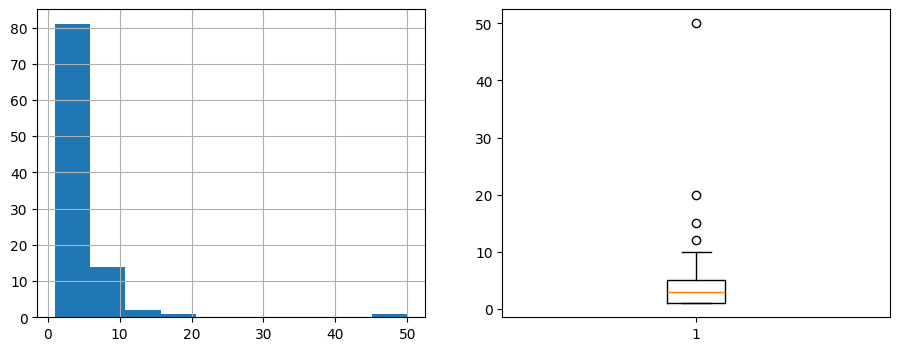

In [5]:
def plot(df):
    _, (ax, ax2) = plt.subplots(1,2, figsize=(11,4))
    ax.hist(df["Amount"])
    ax.grid(True)
    ax2.boxplot(df["Amount"])  # коробчата діаграма або "ящик з вусами" - візуалізація розподілу даних з стат. показниками
    plt.show()                 # ящик - IQR - інтерквартильний розмах (Q1-Q3), лінія в ящику - Q2,
                               # вуса (whiskers) - лінії в межах 1.5 IQR
                               # викиди (outliers) - точки поза вусами

plot(sales)

In [6]:
# Вводимо пропуски
sales.loc[1, "Amount"] = None # 2
sales.loc[2, "Amount"] = None # 5
sales.loc[3, "Amount"] = None # 1

In [7]:
sales.isnull().sum()

Product    0
Price      0
Amount     3
dtype: int64

In [8]:
stat(sales)

|Показник|Значення|
|-|-|
|кількість|99|
|середнє|4.1|
|медіана|3.0|
|мінімум|1.0|
|максимум|50.0|
|Q1|1.0|
|Q2|3.0|
|Q3|5.0|
|P-10|1.0|
|P-90|8.0|
|P-95|10.0|

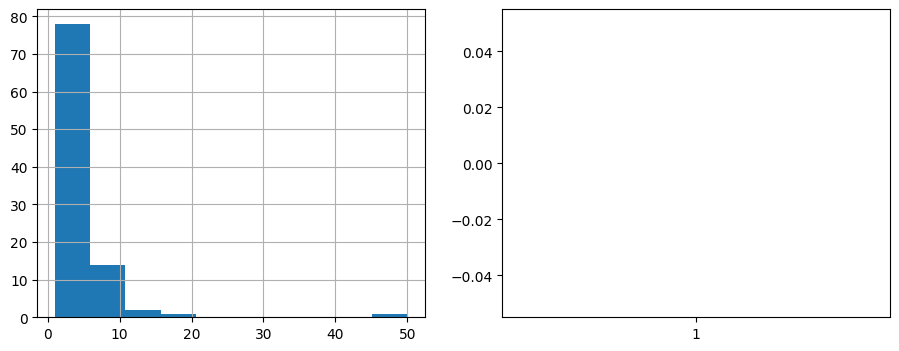

In [9]:
plot(sales)  # за наявності пропусків коробчаста діаграма не виводиться

In [10]:
# Видаляємо пропуски
sales = sales.dropna()
sales.isnull().sum()

Product    0
Price      0
Amount     0
dtype: int64

In [11]:
stat(sales)

|Показник|Значення|
|-|-|
|кількість|96|
|середнє|4.1|
|медіана|3.0|
|мінімум|1.0|
|максимум|50.0|
|Q1|1.0|
|Q2|3.0|
|Q3|5.0|
|P-10|1.0|
|P-90|8.0|
|P-95|10.0|

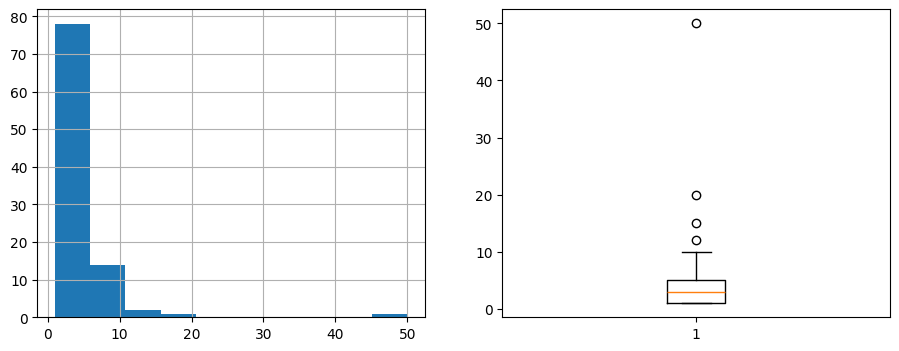

In [12]:
plot(sales)

<table>
    <tr>
        <td>
            <h2>Завдання 2</h2>
Потрібно змоделювати вибірку розмірів замовлень із додаванням викидів і провести базовий статистичний аналіз. Усе необхідно запрограмувати в Python з використанням pandas, NumPy і Matplotlib.
            <ul>
                <li>Створіть одновимірний масив додатних чисел і додайте кілька аномально великих значень.</li>                
                <li>Перетворіть масив на таблицю з одним стовпчиком.</li>
                <li>Розрахуйте середнє, медіану, стандартне відхилення, IQR і MAD, коефіцієнти асиметрії та ексцесу.</li>
                <li>Побудуйте гістограму розподілу та коробчату діаграму.</li>
                <li>Визначте частку спостережень, що виходять за "вуса" коробчастої діаграми.</li>
                <li>Виведіть числові результати та графіки.</li>
            </ul>
            <i><b>Попередні дані продажів містять усі необхідні варіанти, тому продовжимо їх використання</b></i>
        </td>
        <td>            
            <h3>Характеристика відхилень (розкиду) значень сукупності</h3>
            <b>стандартне відхилення</b> - середньоквадратичне відхилення - середнє значення квадратів відхилень даних від середнього. Характеризує "скупченість" або "розкид" значень відносно середнього. Велике відхилення - розкид, мале - скупченість.<br/>
            <b>IQR</b> - інтерквартильний розмах - різниця Q3-Q1<br/>
            <b>MAD</b> - неоднозначний термін: Mean/Median Absolute Deviation, через це функція mad() була прибрана з Python, вимагається "ручне" введення формули<br/>
            <b>коефіцієнт асиметрії</b> - або коеф. зміщення (skewness) - відхилення форми розподілу від нормального у бік асиметрії, тобто неоднаковості лівої та правої частин: 0 - симетричний, <0 - ліва асиметрія, більше значень у малій величині<br/>            
            <b>коефіцієнт ексцесу</b> - відхилення від форми (kurtosis) 0 - нормальний розподіл, >0 - гостра вершина, <0 - плоска вершина <br/>
        </td>
    </tr>
</table>